Install Dependencies

In [6]:
!pip install shap praat-parselmouth librosa soundfile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 80.6 MB/s eta 0:00:00


Install & Import Libraries

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc
)

# Base ML models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, Conv1D, MaxPooling1D, Flatten, GRU,
    Input, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
)

import shap

Upload & Load Dataset

In [8]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

if "name" in df.columns:
    df = df.drop(columns=["name"])

X = df.drop("status", axis=1).values
y = df["status"].values

feature_names = df.drop("status", axis=1).columns.tolist()

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Sequence version for CNN/GRU/Transformer
X_seq = X.reshape(X.shape[0], X.shape[1], 1)
Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_seq, y, test_size=0.2, random_state=42, stratify=y
)

Saving parkinsons.csv to parkinsons (1).csv


Preprocessing

In [9]:
def compute_and_print_metrics(model_name, y_true, y_prob):
    y_pred = (y_prob > 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    sens = recall_score(y_true, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp + 1e-9)

    aucv = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print("\n==============================")
    print(f"Model: {model_name}")
    print(f"Accuracy     : {acc:.4f}")
    print(f"Precision    : {prec:.4f}")
    print(f"Sensitivity  : {sens:.4f}")
    print(f"Specificity  : {spec:.4f}")
    print(f"AUC          : {aucv:.4f}")
    print(f"F1-score     : {f1:.4f}")
    print("==============================\n")

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Sensitivity": sens,
        "Specificity": spec,
        "AUC": aucv,
        "F1": f1
    }

results = []
trained_models = {}

Base Paper Models

In [10]:
base_models = {
    "LOGIS": LogisticRegression(max_iter=1000),
    "LOGIS_PEN": LogisticRegression(penalty="l2", solver="liblinear"),
    "BOOST_GLM": GradientBoostingClassifier(),
    "BOOST_GAM": GradientBoostingClassifier(),
    "BOOST_TREE": GradientBoostingClassifier(),
    "RF": RandomForestClassifier(n_estimators=200),
    "DIS": LinearDiscriminantAnalysis(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(probability=True),
    "TREE": DecisionTreeClassifier()
}

for name, model in base_models.items():
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:,1]
    res = compute_and_print_metrics(name, y_test, probs)
    results.append(res)
    trained_models[name] = model


Model: LOGIS
Accuracy     : 0.8718
Precision    : 0.8750
Sensitivity  : 0.9655
Specificity  : 0.6000
AUC          : 0.9069
F1-score     : 0.9180


Model: LOGIS_PEN
Accuracy     : 0.8718
Precision    : 0.8750
Sensitivity  : 0.9655
Specificity  : 0.6000
AUC          : 0.9000
F1-score     : 0.9180


Model: BOOST_GLM
Accuracy     : 0.9231
Precision    : 0.9643
Sensitivity  : 0.9310
Specificity  : 0.9000
AUC          : 0.9690
F1-score     : 0.9474


Model: BOOST_GAM
Accuracy     : 0.9231
Precision    : 0.9643
Sensitivity  : 0.9310
Specificity  : 0.9000
AUC          : 0.9690
F1-score     : 0.9474


Model: BOOST_TREE
Accuracy     : 0.9231
Precision    : 0.9643
Sensitivity  : 0.9310
Specificity  : 0.9000
AUC          : 0.9690
F1-score     : 0.9474


Model: RF
Accuracy     : 0.9231
Precision    : 0.9333
Sensitivity  : 0.9655
Specificity  : 0.8000
AUC          : 0.9707
F1-score     : 0.9492


Model: DIS
Accuracy     : 0.9487
Precision    : 0.9355
Sensitivity  : 1.0000
Specificity  : 0.8000
AUC 

DEEP1, DEEP2, DEEP3 (ANN depths)

In [11]:
def build_ann(layers):
    model = Sequential()
    model.add(Dense(layers[0], activation="relu", input_shape=(X.shape[1],)))
    for u in layers[1:]:
        model.add(Dense(u, activation="relu"))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(optimizer="adam", loss="binary_crossentropy")
    return model

deep_configs = {
    "DEEP1": [64],
    "DEEP2": [128, 64],
    "DEEP3": [256, 128, 64]
}

deep_probs = {}

for name, layers in deep_configs.items():
    m = build_ann(layers)
    m.fit(X_train, y_train, epochs=30, batch_size=16, verbose=0)
    probs = m.predict(X_test).reshape(-1)

    res = compute_and_print_metrics(name, y_test, probs)
    results.append(res)
    trained_models[name] = m
    deep_probs[name] = probs

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

Model: DEEP1
Accuracy     : 0.8462
Precision    : 0.8710
Sensitivity  : 0.9310
Specificity  : 0.6000
AUC          : 0.8759
F1-score     : 0.9000



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

Model: DEEP2
Accuracy     : 0.9231
Precision    : 0.9333
Sensitivity  : 0.9655
Specificity  : 0.8000
AUC          : 0.9793
F1-score     : 0.9492



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

Model: DEEP3
Accuracy     : 0.9487
Precision    : 0.9655
Sensitivity  : 0.9655
Specificity  : 0.9000
AUC          : 0.9862
F1-score     : 0.9655



deep ensemble

In [12]:
ensemble_probs = (deep_probs["DEEP1"] + deep_probs["DEEP2"] + deep_probs["DEEP3"]) / 3.0
res = compute_and_print_metrics("DEEP_EN", y_test, ensemble_probs)
results.append(res)


Model: DEEP_EN
Accuracy     : 0.9231
Precision    : 0.9333
Sensitivity  : 0.9655
Specificity  : 0.8000
AUC          : 0.9897
F1-score     : 0.9492



cnn

In [13]:
cnn = Sequential([
    Conv1D(64,3,activation="relu", input_shape=(X_seq.shape[1],1)),
    MaxPooling1D(2),
    Flatten(),
    Dense(1, activation="sigmoid")
])
cnn.compile(optimizer="adam", loss="binary_crossentropy")
cnn.fit(Xs_train, ys_train, epochs=30, batch_size=16, verbose=0)
probs = cnn.predict(Xs_test).reshape(-1)
res = compute_and_print_metrics("CNN", ys_test, probs)
results.append(res)
trained_models["CNN"] = cnn

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

Model: CNN
Accuracy     : 0.8462
Precision    : 0.8710
Sensitivity  : 0.9310
Specificity  : 0.6000
AUC          : 0.8793
F1-score     : 0.9000



CNN+GRU

In [14]:
cnn_gru = Sequential([
    Conv1D(64,3,activation="relu", input_shape=(X_seq.shape[1],1)),
    MaxPooling1D(2),
    GRU(32),
    Dense(1, activation="sigmoid")
])
cnn_gru.compile(optimizer="adam", loss="binary_crossentropy")
cnn_gru.fit(Xs_train, ys_train, epochs=30, batch_size=16, verbose=0)
probs = cnn_gru.predict(Xs_test).reshape(-1)
res = compute_and_print_metrics("CNN + GRU", ys_test, probs)
results.append(res)
trained_models["CNN + GRU"] = cnn_gru

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 263ms/step

Model: CNN + GRU
Accuracy     : 0.8462
Precision    : 0.8710
Sensitivity  : 0.9310
Specificity  : 0.6000
AUC          : 0.9172
F1-score     : 0.9000



CNN + Graph (Correlation)

In [15]:
corr = np.corrcoef(X_train.T)
X_graph = X @ corr
Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    X_graph, y, test_size=0.2, random_state=42, stratify=y
)

cnn_graph = Sequential([
    Dense(128, activation="relu", input_shape=(Xg_train.shape[1],)),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])
cnn_graph.compile(optimizer="adam", loss="binary_crossentropy")
cnn_graph.fit(Xg_train, yg_train, epochs=30, batch_size=16, verbose=0)
probs = cnn_graph.predict(Xg_test).reshape(-1)
res = compute_and_print_metrics("CNN + Graph", yg_test, probs)
results.append(res)
trained_models["CNN + Graph"] = cnn_graph

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

Model: CNN + Graph
Accuracy     : 0.8462
Precision    : 0.8710
Sensitivity  : 0.9310
Specificity  : 0.6000
AUC          : 0.9310
F1-score     : 0.9000



gru

In [16]:
gru = Sequential([
    GRU(32, input_shape=(X_seq.shape[1],1)),
    Dense(1, activation="sigmoid")
])
gru.compile(optimizer="adam", loss="binary_crossentropy")
gru.fit(Xs_train, ys_train, epochs=30, batch_size=16, verbose=0)
probs = gru.predict(Xs_test).reshape(-1)
res = compute_and_print_metrics("GRU", ys_test, probs)
results.append(res)
trained_models["GRU"] = gru

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step

Model: GRU
Accuracy     : 0.8718
Precision    : 0.8750
Sensitivity  : 0.9655
Specificity  : 0.6000
AUC          : 0.9069
F1-score     : 0.9180



Transformer

In [17]:
def build_transformer(input_shape):
    inputs = Input(shape=input_shape)
    x = MultiHeadAttention(num_heads=4, key_dim=16)(inputs, inputs)
    x = LayerNormalization()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation="relu")(x)
    outputs = Dense(1, activation="sigmoid")(x)
    return Model(inputs, outputs)

transformer = build_transformer((X_seq.shape[1],1))
transformer.compile(optimizer="adam", loss="binary_crossentropy")
transformer.fit(Xs_train, ys_train, epochs=30, batch_size=16, verbose=0)
probs = transformer.predict(Xs_test).reshape(-1)
res = compute_and_print_metrics("Transformer", ys_test, probs)
results.append(res)
trained_models["Transformer"] = transformer

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step

Model: Transformer
Accuracy     : 0.7436
Precision    : 0.7436
Sensitivity  : 1.0000
Specificity  : 0.0000
AUC          : 0.4862
F1-score     : 0.8529



Autoencoder + Classifier

In [18]:
inp = Input(shape=(X_train.shape[1],))
enc = Dense(64, activation="relu")(inp)
enc = Dense(32, activation="relu")(enc)
dec = Dense(64, activation="relu")(enc)
dec = Dense(X_train.shape[1], activation="linear")(dec)

autoencoder = Model(inp, dec)
encoder = Model(inp, enc)

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.fit(X_train, X_train, epochs=50, batch_size=16, verbose=0)

X_train_enc = encoder.predict(X_train)
X_test_enc = encoder.predict(X_test)

ae_clf = Sequential([
    Dense(32, activation="relu", input_shape=(X_train_enc.shape[1],)),
    Dense(1, activation="sigmoid")
])
ae_clf.compile(optimizer="adam", loss="binary_crossentropy")
ae_clf.fit(X_train_enc, y_train, epochs=30, batch_size=16, verbose=0)

probs = ae_clf.predict(X_test_enc).reshape(-1)
res = compute_and_print_metrics("Autoencoder + Classifier", y_test, probs)
results.append(res)
trained_models["Autoencoder + Classifier"] = ae_clf

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

Model: Autoencoder + Classifier
Accuracy     : 0.8718
Precision    : 0.8529
Sensitivity  : 1.0000
Specificity  : 0.5000
AUC          : 0.9000
F1-score     : 0.9206



Deep Belief Network

In [19]:
dbn = Sequential([
    Dense(128, activation="relu", input_shape=(X.shape[1],)),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])
dbn.compile(optimizer="adam", loss="binary_crossentropy")
dbn.fit(X_train, y_train, epochs=40, batch_size=16, verbose=0)
probs = dbn.predict(X_test).reshape(-1)
res = compute_and_print_metrics("DBN", y_test, probs)
results.append(res)
trained_models["DBN"] = dbn

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step

Model: DBN
Accuracy     : 0.9231
Precision    : 0.9333
Sensitivity  : 0.9655
Specificity  : 0.8000
AUC          : 0.9862
F1-score     : 0.9492



Final Table

In [20]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Sensitivity,Specificity,AUC,F1
0,LOGIS,0.871795,0.875000,0.965517,0.6,0.906897,0.918033
1,LOGIS_PEN,0.871795,0.875000,0.965517,0.6,0.900000,0.918033
2,BOOST_GLM,0.923077,0.964286,0.931034,0.9,0.968966,0.947368
3,BOOST_GAM,0.923077,0.964286,0.931034,0.9,0.968966,0.947368
4,BOOST_TREE,0.923077,0.964286,0.931034,0.9,0.968966,0.947368
5,RF,0.923077,0.933333,0.965517,0.8,0.970690,0.949153
6,DIS,0.948718,0.935484,1.000000,0.8,0.975862,0.966667
7,KNN,0.948718,1.000000,0.931034,1.0,0.989655,0.964286
8,SVM,0.923077,0.906250,1.000000,0.7,0.958621,0.950820
9,TREE,0.820513,0.892857,0.862069,0.7,0.781034,0.877193


Box plots of all tables,models

In [27]:
# ================================
# Suppress warnings (optional but clean output)
# ================================
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, GRU, Input, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D

# ================================
# Boxplot experiment settings
# ================================
N_RUNS = 5

boxplot_records = []

# ================================
# Loop over multiple runs
# ================================
for run in range(N_RUNS):
    print(f"\n===== Run {run+1}/{N_RUNS} =====")

    # New split each run
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=42 + run, stratify=y
    )

    # Sequence versions for CNN/GRU/Transformer
    X_tr_seq = X_tr.reshape(X_tr.shape[0], X_tr.shape[1], 1)
    X_te_seq = X_te.reshape(X_te.shape[0], X_te.shape[1], 1)

    # ---------- CNN ----------
    cnn = Sequential([
        Conv1D(64, 3, activation="relu", input_shape=(X_tr_seq.shape[1], 1)),
        MaxPooling1D(2),
        Flatten(),
        Dense(1, activation="sigmoid")
    ])
    cnn.compile(optimizer="adam", loss="binary_crossentropy")
    cnn.fit(X_tr_seq, y_tr, epochs=20, batch_size=16, verbose=0)
    probs = cnn.predict(X_te_seq).reshape(-1)
    acc = accuracy_score(y_te, (probs > 0.5).astype(int))
    boxplot_records.append({"Model": "CNN", "Accuracy": acc})

    # ---------- CNN + GRU ----------
    cnn_gru = Sequential([
        Conv1D(64, 3, activation="relu", input_shape=(X_tr_seq.shape[1], 1)),
        MaxPooling1D(2),
        GRU(32),
        Dense(1, activation="sigmoid")
    ])
    cnn_gru.compile(optimizer="adam", loss="binary_crossentropy")
    cnn_gru.fit(X_tr_seq, y_tr, epochs=20, batch_size=16, verbose=0)
    probs = cnn_gru.predict(X_te_seq).reshape(-1)
    acc = accuracy_score(y_te, (probs > 0.5).astype(int))
    boxplot_records.append({"Model": "CNN + GRU", "Accuracy": acc})

    # ---------- GRU ----------
    gru = Sequential([
        GRU(32, input_shape=(X_tr_seq.shape[1], 1)),
        Dense(1, activation="sigmoid")
    ])
    gru.compile(optimizer="adam", loss="binary_crossentropy")
    gru.fit(X_tr_seq, y_tr, epochs=20, batch_size=16, verbose=0)
    probs = gru.predict(X_te_seq).reshape(-1)
    acc = accuracy_score(y_te, (probs > 0.5).astype(int))
    boxplot_records.append({"Model": "GRU", "Accuracy": acc})

    # ---------- DBN ----------
    dbn = Sequential([
        Dense(128, activation="relu", input_shape=(X_tr.shape[1],)),
        Dense(64, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    dbn.compile(optimizer="adam", loss="binary_crossentropy")
    dbn.fit(X_tr, y_tr, epochs=20, batch_size=16, verbose=0)
    probs = dbn.predict(X_te).reshape(-1)
    acc = accuracy_score(y_te, (probs > 0.5).astype(int))
    boxplot_records.append({"Model": "DBN", "Accuracy": acc})

    # ---------- CNN + Graph ----------
    corr = np.corrcoef(X_tr.T)
    X_tr_graph = X_tr @ corr
    X_te_graph = X_te @ corr

    cnn_graph = Sequential([
        Dense(128, activation="relu", input_shape=(X_tr_graph.shape[1],)),
        Dense(64, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    cnn_graph.compile(optimizer="adam", loss="binary_crossentropy")
    cnn_graph.fit(X_tr_graph, y_tr, epochs=20, batch_size=16, verbose=0)
    probs = cnn_graph.predict(X_te_graph).reshape(-1)
    acc = accuracy_score(y_te, (probs > 0.5).astype(int))
    boxplot_records.append({"Model": "CNN + Graph", "Accuracy": acc})

    # ---------- Transformer ----------
    def build_transformer(input_shape):
        inputs = Input(shape=input_shape)
        x = MultiHeadAttention(num_heads=4, key_dim=16)(inputs, inputs)
        x = LayerNormalization()(x)
        x = GlobalAveragePooling1D()(x)
        x = Dense(64, activation="relu")(x)
        outputs = Dense(1, activation="sigmoid")(x)
        return Model(inputs, outputs)

    transformer = build_transformer((X_tr_seq.shape[1], 1))
    transformer.compile(optimizer="adam", loss="binary_crossentropy")
    transformer.fit(X_tr_seq, y_tr, epochs=20, batch_size=16, verbose=0)
    probs = transformer.predict(X_te_seq).reshape(-1)
    acc = accuracy_score(y_te, (probs > 0.5).astype(int))
    boxplot_records.append({"Model": "Transformer", "Accuracy": acc})

    # ---------- Autoencoder + Classifier ----------
    inp = Input(shape=(X_tr.shape[1],))
    enc = Dense(64, activation="relu")(inp)
    enc = Dense(32, activation="relu")(enc)
    dec = Dense(64, activation="relu")(enc)
    dec = Dense(X_tr.shape[1], activation="linear")(dec)

    autoencoder = Model(inp, dec)
    encoder = Model(inp, enc)
    autoencoder.compile(optimizer="adam", loss="mse")
    autoencoder.fit(X_tr, X_tr, epochs=30, batch_size=16, verbose=0)

    X_tr_enc = encoder.predict(X_tr)
    X_te_enc = encoder.predict(X_te)

    ae_clf = Sequential([
        Dense(32, activation="relu", input_shape=(X_tr_enc.shape[1],)),
        Dense(1, activation="sigmoid")
    ])
    ae_clf.compile(optimizer="adam", loss="binary_crossentropy")
    ae_clf.fit(X_tr_enc, y_tr, epochs=20, batch_size=16, verbose=0)
    probs = ae_clf.predict(X_te_enc).reshape(-1)
    acc = accuracy_score(y_te, (probs > 0.5).astype(int))
    boxplot_records.append({"Model": "Autoencoder + Classifier", "Accuracy": acc})


===== Run 1/5 =====
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

===== Run 2/5 =====
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 360ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

===== Run 3/5 =====
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 342ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 242ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
5/5 ━━━━━━━━━━━━

In [28]:
boxplot_df = pd.DataFrame(boxplot_records)

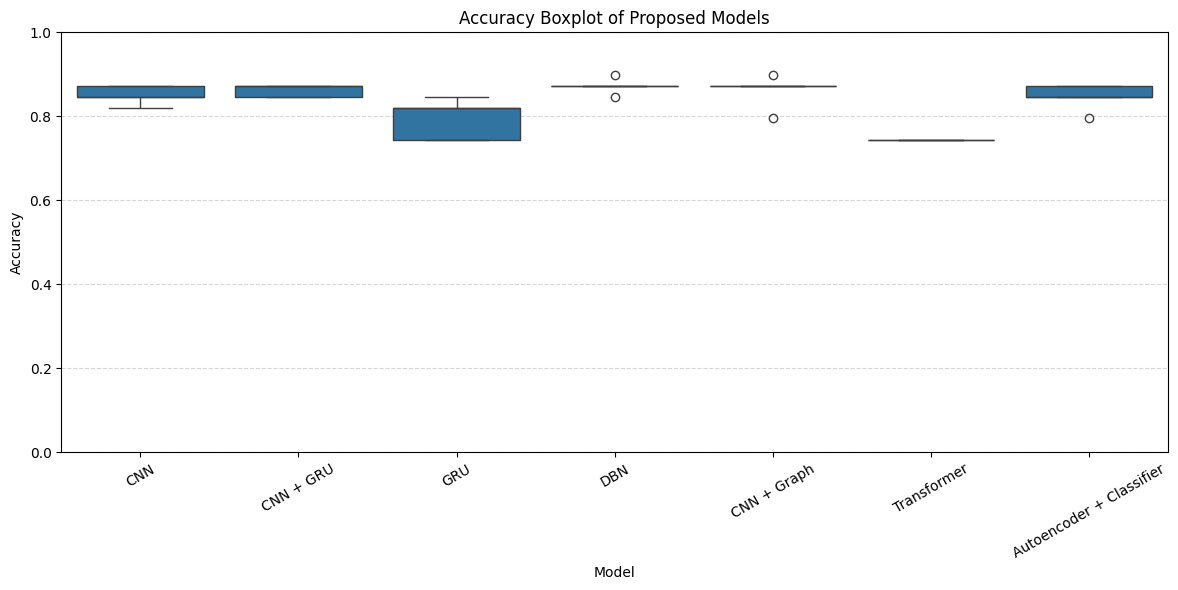

In [29]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=boxplot_df, x="Model", y="Accuracy")
plt.title("Accuracy Boxplot of Proposed Models")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("boxplot_proposed_models.png", dpi=150, bbox_inches="tight")
plt.show()

roc curves

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


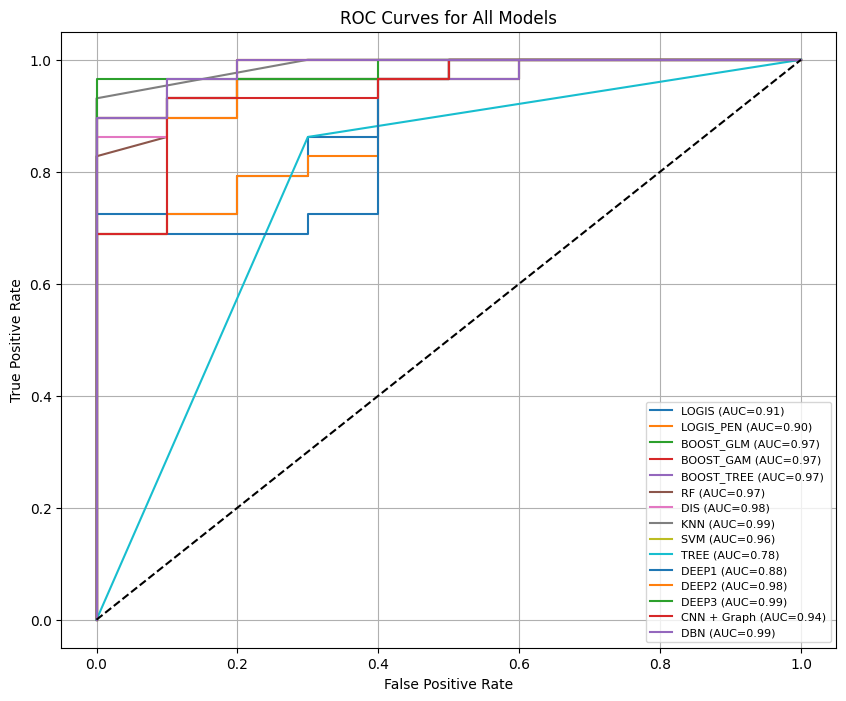

In [22]:
plt.figure(figsize=(10,8))

for name, model in trained_models.items():
    try:
        probs = model.predict_proba(X_test)[:,1]
    except:
        try:
            probs = model.predict(X_test).reshape(-1)
        except:
            continue

    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(fontsize=8)
plt.grid(True)
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

Accuracy graphs

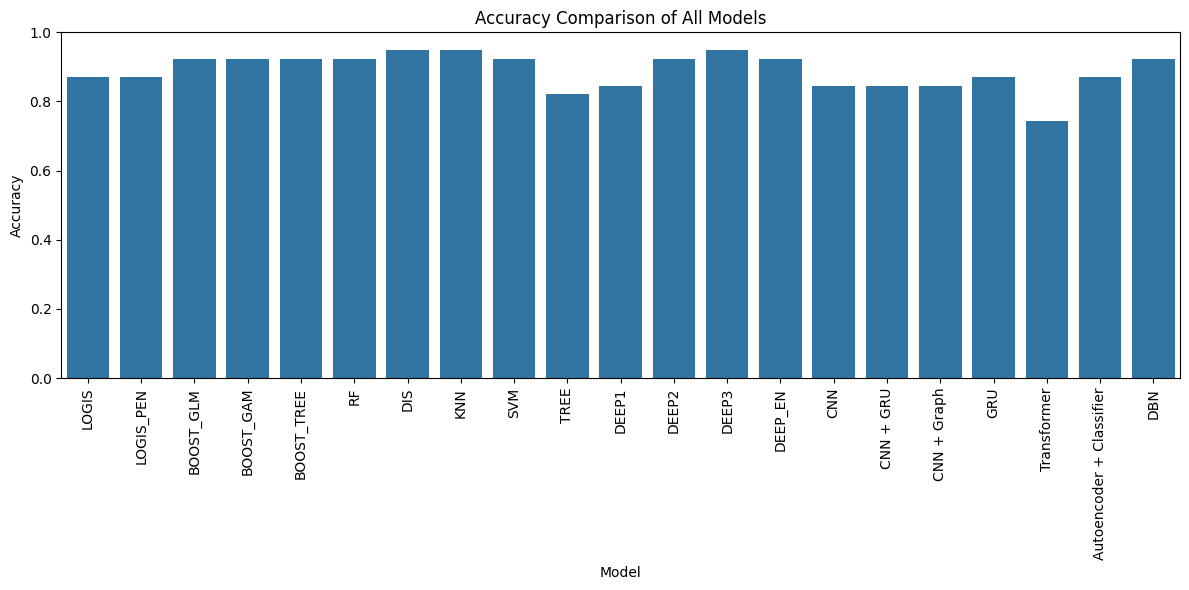

In [23]:
plt.figure(figsize=(12,6))
sns.barplot(data=results_df, x="Model", y="Accuracy")
plt.xticks(rotation=90)
plt.title("Accuracy Comparison of All Models")
plt.ylim(0,1)
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150)
plt.show()

save best model

In [24]:
proposed_names = [
    "CNN", "CNN + GRU", "CNN + Graph", "GRU",
    "Transformer", "DBN", "Autoencoder + Classifier"
]

proposed_df = results_df[results_df["Model"].isin(proposed_names)]
best_row = proposed_df.sort_values("Accuracy", ascending=False).iloc[0]

best_model_name = best_row["Model"]
best_model = trained_models[best_model_name]

print("🏆 Best Proposed Model:", best_model_name)
print("Accuracy:", best_row["Accuracy"])

pickle.dump(best_model, open("parkinson_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(feature_names, open("feature_names.pkl", "wb"))

print("💾 Saved: parkinson_model.pkl, scaler.pkl, feature_names.pkl")

🏆 Best Proposed Model: DBN
Accuracy: 0.9230769230769231
💾 Saved: parkinson_model.pkl, scaler.pkl, feature_names.pkl


SHAP Explainability

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


  0%|          | 0/39 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
6538/6538 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
6538/6538 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
6538/6538 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
6538/6538 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
6538/6538 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
6538/6538 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
6538/6538 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
6538/6538 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
6538/6538 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
6538/6538 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
6538/6538 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
6538/6538 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

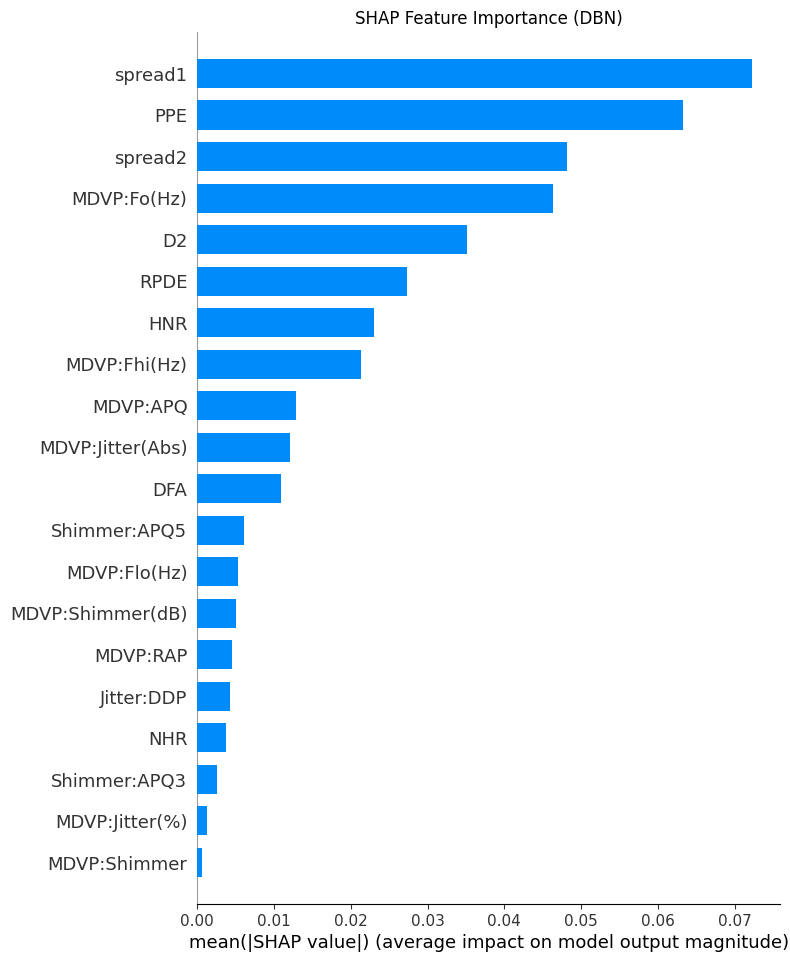

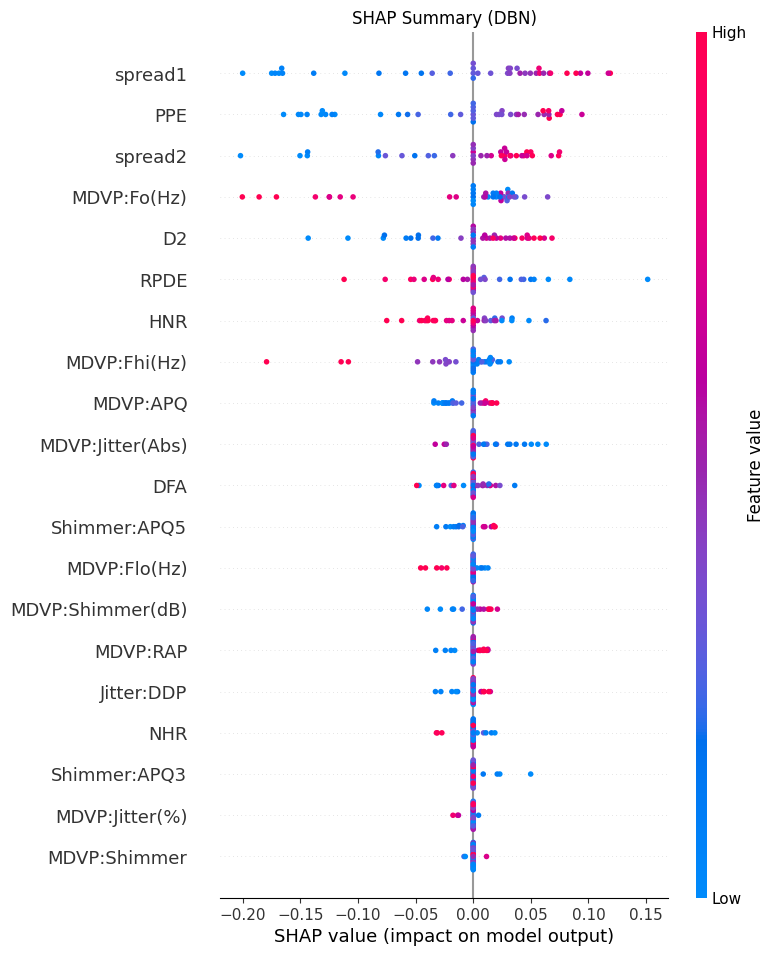

In [25]:
# Use KernelExplainer (works for any model)
background = X_train[np.random.choice(X_train.shape[0], size=min(100, X_train.shape[0]), replace=False)]

def predict_fn(X):
    try:
        return best_model.predict(X).reshape(-1)
    except:
        return best_model.predict_proba(X)[:,1]

explainer = shap.KernelExplainer(predict_fn, background)
X_explain = X_test[:50]
shap_values = explainer.shap_values(X_explain)

# Bar plot
shap.summary_plot(shap_values, X_explain, feature_names=feature_names, plot_type="bar", show=False)
plt.title(f"SHAP Feature Importance ({best_model_name})")
plt.savefig("shap_summary_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# Beeswarm
shap.summary_plot(shap_values, X_explain, feature_names=feature_names, show=False)
plt.title(f"SHAP Summary ({best_model_name})")
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()